# Libs & Setup

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import logging
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import talib as ta
from torch import optim
from torch.utils.data import DataLoader, Dataset, TensorDataset, random_split
from tqdm import tqdm
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from torch.optim import AdamW
from utils import scale, inverse_scale, inverse_scale_pair, inspect, inverse_transform, monte_carlo_statistic
from utils.paths import CHECKPOINTS_DIR, REPORTS_SIM_DIR, RESULTS_DIR, REPORTS_QS_DIR
from pypfopt import risk_models, expected_returns, plotting, EfficientFrontier

# Own Libs
from config import *
from entities import *
from strategies import *
from datasets import *
from engine import Engine
from models import DiffusionTransformer, Diffusion

/home/narodom.y@FUSION.LAB/.conda/envs/tsgenai/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# logging.basicConfig(level=logging.DEBUG)
logging.getLogger('matplotlib').setLevel(logging.WARNING)

In [3]:
cfg = TrainConfig(epochs=2, window_size=64, device=torch.device("cuda:1"))
window_size = cfg.window_size
device = cfg.device
batch_size = cfg.batch_size
batch_size_exp = 1
epochs = cfg.epochs
sim_steps = cfg.steps_to_sim
num_sims = cfg.num_sims

# Optimizer
weight_decay = cfg.optimizer.weight_decay
lr = cfg.optimizer.lr
stride = 1
time_range = {
    'start_date': '2021-01-01',
    'end_date': '2024-12-31'
}

ddpm = {
    'timesteps': int(1000),
    'beta_start': 0.0001,
    'beta_end': 0.02
}

ddpm_transformer = {
    'window_size': window_size,
    'd_model': 64,
    'nhead': 4,
    'num_layers': 32,
    'dim_feedforward': 512,
    'dropout': 0.1
}

ckpt_name = f"ddpm_transformer_d{ddpm_transformer['d_model']}_l{ddpm_transformer['num_layers']}"

In [4]:
def time_range_info(df):
    info = (df.index.min(), df.index.max())
    print(f"Data range: {info[0]} to {info[1]}")
    
    duration = df.index.max() - df.index.min()
    print(f"Total duration: {duration}")

def time_range_mask(df, start_date, end_date):
    mask = (df.index >= start_date) & (df.index <= end_date)
    return mask

# Data

In [5]:
symbols = ['AAPL', 'TSLA', 'MSFT', 'NVDA', 'GOOGL', 'AMZN', 'GOOG', 'META', 'AVGO', 'ORCL', 'CRM', 'ADBE', 'AMD', 'CSCO']
freq = "1d"

# Basket
basket = Basket(symbols=symbols)
basket.load_all_assets(freq=freq)

print(f"Basket data shape: {basket.data.shape}")
basket.data.head(5)

Basket data shape: (2760, 70)


AAPL                                                \
                Close       High        Low       Open       Volume   
Date                                                                  
2015-01-02  24.261047  24.729270  23.821672  24.718174  212818400.0   
2015-01-05  23.577574  24.110150  23.391173  24.030263  257142000.0   
2015-01-06  23.579794  23.839424  23.218085  23.641928  263188400.0   
2015-01-07  23.910433  24.010290  23.677430  23.788384  160423600.0   
2015-01-08  24.829119  24.886815  24.121236  24.238848  237458000.0   

                 TSLA                                             ...   AMD  \
                Close       High        Low       Open    Volume  ... Close   
Date                                                              ...         
2015-01-02  14.620667  14.883333  14.217333  14.858000  71466000  ...  2.67   
2015-01-05  14.006000  14.433333  13.810667  14.303333  80527500  ...  2.66   
2015-01-06  14.085333  14.280000  13.614000  14.004000  93928500  ...  2.63   
2015-01-07  14.063333  14.318667  13.985333  14.223333  44526000  ...  2.58   
2015-01-08  14.041333  14.253333  14.000667  14.187333  51637500  ...  2.61   

                                               CSCO                        \
            High   Low  Open      Volume      Close       High        Low   
Date                                                                        
2015-01-02  2.67  2.67  2.67         0.0  19.815605  20.181631  19.650534   
2015-01-05  2.70  2.64  2.67   8878200.0  19.420874  19.700776  19.377812   
2015-01-06  2.66  2.55  2.65  13912500.0  19.413698  19.865848  19.406522   
2015-01-07  2.65  2.54  2.63  12377600.0  19.593126  19.664896  19.363463   
2015-01-08  2.65  2.56  2.59  11136600.0  19.743843  20.160107  19.715135   

                                   
                 Open      Volume  
Date                               
2015-01-02  19.995029  22926500.0  
2015-01-05  19.607475  29460600.0  
2015-01-06  19.478291  47297600.0  
2015-01-07  19.478295  27570800.0  
2015-01-08  19.765374  40907000.0  

[5 rows x 70 columns]

In [6]:
time_range_info(basket.data)

for symbol, asset in basket.assets.items():
    mask = time_range_mask(asset.data, time_range['start_date'], time_range['end_date'])
    asset.data = asset.data[mask]

time_range_info(basket.data)

Data range: 2015-01-02 00:00:00 to 2025-12-22 00:00:00
Total duration: 4007 days 00:00:00
Data range: 2021-01-04 00:00:00 to 2024-12-31 00:00:00
Total duration: 1457 days 00:00:00


In [7]:
targets = ["Close"]
features = basket.get_unique_features()
print(f"Features:\t{features}\nTargets:\t{targets}")

Features:	['Close', 'High', 'Low', 'Open', 'Volume']
Targets:	['Close']


In [8]:
df = basket.data
df.ffill(inplace=True)
df.head()

AAPL                                                 \
                 Close        High         Low        Open     Volume   
Date                                                                    
2021-01-04  126.096588  130.189048  123.514437  130.101356  143301900   
2021-01-05  127.655609  128.366929  125.141666  125.589894   97664900   
2021-01-06  123.358521  127.694587  123.144152  124.449847  155088000   
2021-01-07  127.567940  128.259768  124.586290  125.073488  109578200   
2021-01-08  128.668976  129.234127  126.895568  129.039236  105158200   

                  TSLA                                                 ...  \
                 Close        High         Low        Open     Volume  ...   
Date                                                                   ...   
2021-01-04  243.256668  248.163330  239.063339  239.820007  145914600  ...   
2021-01-05  245.036667  246.946671  239.733337  241.220001   96735600  ...   
2021-01-06  251.993332  258.000000  249.699997  252.830002  134100000  ...   
2021-01-07  272.013336  272.329987  258.399994  259.209991  154496700  ...   
2021-01-08  293.339996  294.829987  279.463318  285.333344  225166500  ...   

                  AMD                                                  CSCO  \
                Close       High        Low       Open    Volume      Close   
Date                                                                          
2021-01-04  92.300003  96.059998  90.919998  92.110001  51802600  38.239326   
2021-01-05  92.769997  93.209999  91.410004  92.099998  34208000  38.256729   
2021-01-06  90.330002  92.279999  89.459999  91.620003  51911700  38.622074   
2021-01-07  95.160004  95.510002  91.199997  91.330002  42897200  39.109196   
2021-01-08  94.580002  96.400002  93.269997  95.980003  39816400  39.196186   

                                                       
                 High        Low       Open    Volume  
Date                                                   
2021-01-04  38.595972  37.708707  38.543782  24392500  
2021-01-05  38.335017  37.734811  37.995770  17763700  
2021-01-06  39.030909  38.178440  38.387210  21823100  
2021-01-07  39.239677  38.422000  38.448099  18218800  
2021-01-08  39.500638  38.491593  38.691662  20936300  

[5 rows x 70 columns]

In [9]:
assets = df.columns.get_level_values(0).unique()
assets

Index(['AAPL', 'TSLA', 'MSFT', 'NVDA', 'GOOGL', 'AMZN', 'GOOG', 'META', 'AVGO',
       'ORCL', 'CRM', 'ADBE', 'AMD', 'CSCO'],
      dtype='object')

In [10]:
time_prd = 20
processed_dfs = []
day_shift = 1

for symbol in assets:
    asset_df = df.xs(symbol, level=0, axis=1).copy()
    for target in targets:
        s = asset_df[target]
        close_price = asset_df['Close']
        # Calc Log Return 
        asset_df[f"Log_Returns {target}"] = np.log(s).diff()
        asset_df[f"Distance_SMA_{time_prd} {target}"] = ((close_price - ta.SMA(s, timeperiod=time_prd)) / close_price).shift(day_shift)
        asset_df[f"Distance_EMA_{time_prd} {target}"] = ((close_price - ta.EMA(s, timeperiod=time_prd)) / close_price).shift(day_shift)
        # asset_df[f"SMA_{time_prd} {target}"] = ta.SMA(s, timeperiod=time_prd).shift(day_shift)
        # asset_df[f"EMA_{time_prd} {target}"] = ta.EMA(s, timeperiod=time_prd).shift(day_shift)
        # asset_df[f"RSI_{time_prd} {target}"] = ta.RSI(s, timeperiod=time_prd).shift(day_shift)
    asset_df.columns = pd.MultiIndex.from_product([[symbol], asset_df.columns])
    processed_dfs.append(asset_df)
    
df_updated = pd.concat(processed_dfs, axis=1)
df_updated.head()

AAPL                                                 \
                 Close        High         Low        Open     Volume   
Date                                                                    
2021-01-04  126.096588  130.189048  123.514437  130.101356  143301900   
2021-01-05  127.655609  128.366929  125.141666  125.589894   97664900   
2021-01-06  123.358521  127.694587  123.144152  124.449847  155088000   
2021-01-07  127.567940  128.259768  124.586290  125.073488  109578200   
2021-01-08  128.668976  129.234127  126.895568  129.039236  105158200   

                                                                          \
           Log_Returns Close Distance_SMA_20 Close Distance_EMA_20 Close   
Date                                                                       
2021-01-04               NaN                   NaN                   NaN   
2021-01-05          0.012288                   NaN                   NaN   
2021-01-06         -0.034241                   NaN                   NaN   
2021-01-07          0.033554                   NaN                   NaN   
2021-01-08          0.008594                   NaN                   NaN   

                  TSLA              ...                   AMD  \
                 Close        High  ... Distance_SMA_20 Close   
Date                                ...                         
2021-01-04  243.256668  248.163330  ...                   NaN   
2021-01-05  245.036667  246.946671  ...                   NaN   
2021-01-06  251.993332  258.000000  ...                   NaN   
2021-01-07  272.013336  272.329987  ...                   NaN   
2021-01-08  293.339996  294.829987  ...                   NaN   

                                       CSCO                                   \
           Distance_EMA_20 Close      Close       High        Low       Open   
Date                                                                           
2021-01-04                   NaN  38.239326  38.595972  37.708707  38.543782   
2021-01-05                   NaN  38.256729  38.335017  37.734811  37.995770   
2021-01-06                   NaN  38.622074  39.030909  38.178440  38.387210   
2021-01-07                   NaN  39.109196  39.239677  38.422000  38.448099   
2021-01-08                   NaN  39.196186  39.500638  38.491593  38.691662   

                                                              \
              Volume Log_Returns Close Distance_SMA_20 Close   
Date                                                           
2021-01-04  24392500               NaN                   NaN   
2021-01-05  17763700          0.000455                   NaN   
2021-01-06  21823100          0.009505                   NaN   
2021-01-07  18218800          0.012534                   NaN   
2021-01-08  20936300          0.002222                   NaN   

                                  
           Distance_EMA_20 Close  
Date                              
2021-01-04                   NaN  
2021-01-05                   NaN  
2021-01-06                   NaN  
2021-01-07                   NaN  
2021-01-08                   NaN  

[5 rows x 112 columns]

In [11]:
nan_counts = df_updated.isna().sum()
print(nan_counts[nan_counts > 0])

AAPL   Log_Returns Close         1
       Distance_SMA_20 Close    20
       Distance_EMA_20 Close    20
TSLA   Log_Returns Close         1
       Distance_SMA_20 Close    20
       Distance_EMA_20 Close    20
MSFT   Log_Returns Close         1
       Distance_SMA_20 Close    20
       Distance_EMA_20 Close    20
NVDA   Log_Returns Close         1
       Distance_SMA_20 Close    20
       Distance_EMA_20 Close    20
GOOGL  Log_Returns Close         1
       Distance_SMA_20 Close    20
       Distance_EMA_20 Close    20
AMZN   Log_Returns Close         1
       Distance_SMA_20 Close    20
       Distance_EMA_20 Close    20
GOOG   Log_Returns Close         1
       Distance_SMA_20 Close    20
       Distance_EMA_20 Close    20
META   Log_Returns Close         1
       Distance_SMA_20 Close    20
       Distance_EMA_20 Close    20
AVGO   Log_Returns Close         1
       Distance_SMA_20 Close    20
       Distance_EMA_20 Close    20
ORCL   Log_Returns Close         1
       Distance_SMA_

In [12]:
df_updated.dropna(inplace=True)
nan_counts = df_updated.isna().sum()
print(nan_counts[nan_counts > 0])
df_updated

Series([], dtype: int64)


AAPL                                                \
                 Close        High         Low        Open    Volume   
Date                                                                   
2021-02-02  131.533722  132.819917  131.163447  132.254765  83305400   
2021-02-03  130.510605  132.293751  130.189052  132.283998  89880900   
2021-02-04  133.872253  133.881992  131.143942  132.810165  84183100   
2021-02-05  133.457504  134.101570  132.579243  134.033268  75693800   
2021-02-08  133.603882  133.652677  131.661931  132.745127  71297200   
...                ...         ...         ...         ...       ...   
2024-12-24  257.286682  257.296626  254.386957  254.586262  23234700   
2024-12-26  258.103729  259.179926  256.718662  257.276679  27237100   
2024-12-27  254.685867  257.784882  252.164818  256.917934  42355300   
2024-12-30  251.307877  252.603281  249.863009  251.337769  35557500   
2024-12-31  249.534180  252.384064  248.547676  251.547039  39480700   

                                                                          \
           Log_Returns Close Distance_SMA_20 Close Distance_EMA_20 Close   
Date                                                                       
2021-02-02          0.006317              0.007813              0.007813   
2021-02-03         -0.007809              0.011994              0.012721   
2021-02-04          0.025432              0.003154              0.004507   
2021-02-05         -0.003103              0.024259              0.026695   
2021-02-08          0.001096              0.019020              0.021416   
...                      ...                   ...                   ...   
2024-12-24          0.011413              0.040126              0.038451   
2024-12-26          0.003171              0.046114              0.044661   
2024-12-27         -0.013331              0.044508              0.043144   
2024-12-30         -0.013352              0.027644              0.027417   
2024-12-31         -0.007083              0.011626              0.012978   

                  TSLA              ...                   AMD  \
                 Close        High  ... Distance_SMA_20 Close   
Date                                ...                         
2021-02-02  290.929993  293.500000  ...             -0.043549   
2021-02-03  284.896667  292.693329  ...             -0.027521   
2021-02-04  283.329987  285.500000  ...             -0.036085   
2021-02-05  284.076660  288.256653  ...             -0.035257   
2021-02-08  287.806671  292.589996  ...             -0.030421   
...                ...         ...  ...                   ...   
2024-12-24  462.279999  462.779999  ...             -0.060325   
2024-12-26  454.130005  465.329987  ...             -0.040261   
2024-12-27  431.660004  450.000000  ...             -0.045430   
2024-12-30  417.410004  427.000000  ...             -0.039931   
2024-12-31  403.839996  427.929993  ...             -0.057269   

                                       CSCO                                   \
           Distance_EMA_20 Close      Close       High        Low       Open   
Date                                                                           
2021-02-02             -0.043549  39.865974  39.961657  39.518027  39.596315   
2021-02-03             -0.026651  39.813793  40.153041  39.613724  39.796395   
2021-02-04             -0.034364  41.101185  41.162075  39.813783  39.900768   
2021-02-05             -0.031624  41.823177  42.049341  41.318653  41.379544   
2021-02-08             -0.027975  42.571262  42.919210  42.240716  42.240716   
...                          ...        ...        ...        ...        ...   
2024-12-24             -0.045361  58.345390  58.345390  57.321788  57.321788   
2024-12-26             -0.028384  58.472118  58.550109  57.906701  58.121168   
2024-12-27             -0.034832  58.111423  58.511116  57.653238  58.072428   
2024-12-30             -0.030542  57.701981  57.896953  56.941591  57.604

In [13]:
drop_cols = ['Open', 'High', 'Low', 'Volume']

df_final = df_updated.drop(columns=drop_cols, level=1).copy()
df_final

AAPL                                          \
                 Close Log_Returns Close Distance_SMA_20 Close   
Date                                                             
2021-02-02  131.533722          0.006317              0.007813   
2021-02-03  130.510605         -0.007809              0.011994   
2021-02-04  133.872253          0.025432              0.003154   
2021-02-05  133.457504         -0.003103              0.024259   
2021-02-08  133.603882          0.001096              0.019020   
...                ...               ...                   ...   
2024-12-24  257.286682          0.011413              0.040126   
2024-12-26  258.103729          0.003171              0.046114   
2024-12-27  254.685867         -0.013331              0.044508   
2024-12-30  251.307877         -0.013352              0.027644   
2024-12-31  249.534180         -0.007083              0.011626   

                                        TSLA                    \
           Distance_EMA_20 Close       Close Log_Returns Close   
Date                                                             
2021-02-02              0.007813  290.929993          0.038519   
2021-02-03              0.012721  284.896667         -0.020956   
2021-02-04              0.004507  283.329987         -0.005514   
2021-02-05              0.026695  284.076660          0.002632   
2021-02-08              0.021416  287.806671          0.013045   
...                          ...         ...               ...   
2024-12-24              0.038451  462.279999          0.070991   
2024-12-26              0.044661  454.130005         -0.017787   
2024-12-27              0.043144  431.660004         -0.050745   
2024-12-30              0.027417  417.410004         -0.033569   
2024-12-31              0.012978  403.839996         -0.033050   

                                                              MSFT  \
           Distance_SMA_20 Close Distance_EMA_20 Close       Close   
Date                                                                 
2021-02-02              0.012481              0.012481  230.249481   
2021-02-03              0.041603              0.045054  233.604568   
2021-02-04              0.014311              0.022466  232.652863   
2021-02-05              0.003331              0.015436  232.835480   
2021-02-08              0.003827              0.016307  233.095016   
...                          ...                   ...         ...   
2024-12-24              0.080267              0.066761  436.929138   
2024-12-26              0.129918              0.118267  435.715790   
2024-12-27              0.101543              0.092686  428.177216   
2024-12-30              0.043333              0.041127  422.508331   
2024-12-31              0.002018              0.007593  419.196564   

                              ...                  ADBE                        \
           Log_Returns Close  ... Distance_SMA_20 Close Distance_EMA_20 Close   
Date                          ...                                               
2021-02-02         -0.000584  ...             -0.001523             -0.001523   
2021-02-03          0.014466  ...              0.029354              0.026520   
2021-02-04         -0.004082  ...              0.023682              0.018493   
2021-02-05          0.000785  ...              0.036208              0.030269   
2021-02-08          0.001114  ...              0.040113              0.032271   
...                      ...  ...                   ...                   ...   
2024-12-24          0.009330  ...             -0.120156             -0.085816   
2024-12-26         -0.002781  ...             -0.109253             -0.075011   
2024-12-27         -0.017453  ...             -0.095437             -0.063071   
2024-12-30         -0.013328  ...             -0.096940             -0.064992   
2024-12-31         -0.007869  ...             -0.090748             -0.060272   

                   AMD                              

In [14]:
close_price_df = df_final.xs('Close', level=1, axis=1)
close_price_df

,AAPL,TSLA,MSFT,NVDA,GOOGL,AMZN,GOOG,META,AVGO,ORCL,CRM,ADBE,AMD,CSCO
Date,,,,,,,,,,,,,,
2021-02-02,131.533722,290.929993,230.249481,13.519486,95.236427,169.000000,95.720467,265.227264,42.982567,58.397964,231.762054,484.929993,88.860001,39.865974
2021-02-03,130.510605,284.896667,233.604568,13.493309,102.172020,165.626495,102.800018,264.800354,41.928913,58.210693,232.375610,481.920013,87.889999,39.813793
2021-02-04,133.872253,283.329987,232.652863,13.626689,101.911491,166.550003,102.417633,264.641357,42.419239,59.315540,235.502716,489.380005,87.839996,41.101185
2021-02-05,133.457504,284.076660,232.835480,13.553641,103.658287,167.607498,104.187027,266.240204,42.002819,59.549629,236.403259,492.119995,87.900002,41.823177
2021-02-08,133.603882,287.806671,233.095016,14.399062,103.444397,166.147003,103.934258,264.730743,42.605808,59.090828,236.442825,493.760010,91.470001,42.571262
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,257.286682,462.279999,436.929138,140.189468,195.344940,229.050003,196.932236,605.839600,237.988037,169.721893,342.748352,447.940002,126.290001,58.345390
2024-12-26,258.103729,454.130005,435.715790,139.899521,194.836945,227.050003,196.463745,601.453369,243.627945,169.989227,340.051605,450.160004,125.059998,58.472118
2024-12-27,254.685867,431.660004,428.177216,136.980164,192.007996,223.750000,193.413620,597.924561,240.043442,167.296021,336.797607,446.480011,125.190002,58.111423


In [15]:
target_feature =  "Log_Returns Close"
def create_sequences(df, feature_name, steps: int):
    target_data = df.xs(feature_name, level=1, axis=1)

    sequence_list = []
    # such as steps = 8, loop 0 day to 7 day (include current date)
    for step in range(steps + 1):
        shifted_data = target_data.shift(-step)
        shifted_data.columns = [f"{col}_Day{step}" for col in shifted_data.columns]
        sequence_list.append(shifted_data)

    result_df = pd.concat(sequence_list, axis=1)
    result_df = result_df.sort_index(axis=1)
    return result_df

df_series_seq= create_sequences(df_final, target_feature, 8)
df_series_seq

,AAPL_Day0,AAPL_Day1,AAPL_Day2,AAPL_Day3,AAPL_Day4,AAPL_Day5,AAPL_Day6,AAPL_Day7,AAPL_Day8,ADBE_Day0,...,ORCL_Day8,TSLA_Day0,TSLA_Day1,TSLA_Day2,TSLA_Day3,TSLA_Day4,TSLA_Day5,TSLA_Day6,TSLA_Day7,TSLA_Day8
Date,,,,,,,,,,,,,,,,,,,,,
2021-02-02,0.006317,-0.007809,0.025432,-0.003103,0.001096,-0.006595,-0.004569,-0.001922,0.001774,0.031272,...,0.006042,0.038519,-0.020956,-0.005514,0.002632,0.013045,-0.016300,-0.053982,0.008463,0.005480
2021-02-03,-0.007809,0.025432,-0.003103,0.001096,-0.006595,-0.004569,-0.001922,0.001774,-0.016235,-0.006226,...,-0.015014,-0.020956,-0.005514,0.002632,0.013045,-0.016300,-0.053982,0.008463,0.005480,-0.024686
2021-02-04,0.025432,-0.003103,0.001096,-0.006595,-0.004569,-0.001922,0.001774,-0.016235,-0.017802,0.015361,...,-0.000805,-0.005514,0.002632,0.013045,-0.016300,-0.053982,0.008463,0.005480,-0.024686,0.002421
2021-02-05,-0.003103,0.001096,-0.006595,-0.004569,-0.001922,0.001774,-0.016235,-0.017802,-0.008674,0.005583,...,-0.000322,0.002632,0.013045,-0.016300,-0.053982,0.008463,0.005480,-0.024686,0.002421,-0.013586
2021-02-08,0.001096,-0.006595,-0.004569,-0.001922,0.001774,-0.016235,-0.017802,-0.008674,0.001233,0.003327,...,-0.015260,0.013045,-0.016300,-0.053982,0.008463,0.005480,-0.024686,0.002421,-0.013586,-0.007752
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,0.011413,0.003171,-0.013331,-0.013352,-0.007083,NaN,NaN,NaN,NaN,0.002683,...,NaN,0.070991,-0.017787,-0.050745,-0.033569,-0.033050,NaN,NaN,NaN,NaN
2024-12-26,0.003171,-0.013331,-0.013352,-0.007083,NaN,NaN,NaN,NaN,NaN,0.004944,...,NaN,-0.017787,-0.050745,-0.033569,-0.033050,NaN,NaN,NaN,NaN,NaN
2024-12-27,-0.013331,-0.013352,-0.007083,NaN,NaN,NaN,NaN,NaN,NaN,-0.008208,...,NaN,-0.050745,-0.033569,-0.033050,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
new_columns = []
original_assets = df.columns.levels[0]

for col in df_series_seq.columns:
    for asset in original_assets:
        if col.startswith(asset):
            suffix = col.replace(asset, "") # "_Day+0", "_Day+1"
            new_feature_name = f"{target_feature}{suffix}"
            new_columns.append((asset, new_feature_name))
            break

# df_series_seq
multi_index_cols = pd.MultiIndex.from_tuples(new_columns, names=['Asset', 'Feature'])
df_series_seq.columns = multi_index_cols

df_final_updated = pd.concat([df_final, df_series_seq], axis=1)
df_final_updated = df_final_updated.sort_index(axis=1, level=0)

In [17]:
df_final_updated['AAPL'].columns

Index(['Close', 'Distance_EMA_20 Close', 'Distance_SMA_20 Close',
       'Log_Returns Close', 'Log_Returns Close_Day0', 'Log_Returns Close_Day1',
       'Log_Returns Close_Day2', 'Log_Returns Close_Day3',
       'Log_Returns Close_Day4', 'Log_Returns Close_Day5',
       'Log_Returns Close_Day6', 'Log_Returns Close_Day7',
       'Log_Returns Close_Day8'],
      dtype='object')

In [18]:
target_drop_cols = ["Log_Returns Close"]
df_seq_final = df_final_updated.drop(columns=target_drop_cols, level=1).copy()
df_seq_final.columns.remove_unused_levels()
df_seq_final

AAPL                                              \
                 Close Distance_EMA_20 Close Distance_SMA_20 Close   
Date                                                                 
2021-02-02  131.533722              0.007813              0.007813   
2021-02-03  130.510605              0.012721              0.011994   
2021-02-04  133.872253              0.004507              0.003154   
2021-02-05  133.457504              0.026695              0.024259   
2021-02-08  133.603882              0.021416              0.019020   
...                ...                   ...                   ...   
2024-12-24  257.286682              0.038451              0.040126   
2024-12-26  258.103729              0.044661              0.046114   
2024-12-27  254.685867              0.043144              0.044508   
2024-12-30  251.307877              0.027417              0.027644   
2024-12-31  249.534180              0.012978              0.011626   

                                                          \
           Log_Returns Close_Day0 Log_Returns Close_Day1   
Date                                                       
2021-02-02               0.006317              -0.007809   
2021-02-03              -0.007809               0.025432   
2021-02-04               0.025432              -0.003103   
2021-02-05              -0.003103               0.001096   
2021-02-08               0.001096              -0.006595   
...                           ...                    ...   
2024-12-24               0.011413               0.003171   
2024-12-26               0.003171              -0.013331   
2024-12-27              -0.013331              -0.013352   
2024-12-30              -0.013352              -0.007083   
2024-12-31              -0.007083                    NaN   

                                                          \
           Log_Returns Close_Day2 Log_Returns Close_Day3   
Date                                                       
2021-02-02               0.025432              -0.003103   
2021-02-03              -0.003103               0.001096   
2021-02-04               0.001096              -0.006595   
2021-02-05              -0.006595              -0.004569   
2021-02-08              -0.004569              -0.001922   
...                           ...                    ...   
2024-12-24              -0.013331              -0.013352   
2024-12-26              -0.013352              -0.007083   
2024-12-27              -0.007083                    NaN   
2024-12-30                    NaN                    NaN   
2024-12-31                    NaN                    NaN   

                                                          \
           Log_Returns Close_Day4 Log_Returns Close_Day5   
Date                                                       
2021-02-02               0.001096              -0.006595   
2021-02-03              -0.006595              -0.004569   
2021-02-04              -0.004569              -0.001922   
2021-02-05              -0.001922               0.001774   
2021-02-08               0.001774              -0.016235   
...                           ...                    ...   
2024-12-24              -0.007083                    NaN   
2024-12-26                    NaN                    NaN   
2024-12-27                    NaN                    NaN   
2024-12-30                    NaN                    NaN   
2024-12-31                    NaN                    NaN   

                                   ...                  TSLA  \
           Log_Returns Close_Day6  ... Distance_SMA_20 Close   
Date                               ...                         
2021-02-02              -0.004569  ...              0.012481   
2021-02-03              -0.001922  ...              0.041603   
2021-02-04               0.001774  ...              0.014311   
2021-02-05              -0.016235  ...              0.003331   
2021-02-08              -0.017802  ...              0.003827   
..

In [19]:
df_seq_final.dropna(inplace=True)
nan_counts = df_updated.isna().sum()
print(nan_counts[nan_counts > 0])
df_seq_final.shape

Series([], dtype: int64)


(977, 168)

In [20]:
n_obs = len(df_seq_final)
n_assets = len(df_seq_final.columns.get_level_values(0).unique())
n_features = len(df_seq_final.columns.get_level_values(1).unique())

print(n_obs, n_assets, n_features)

977 14 12


In [21]:
market = df_seq_final.values.reshape(n_obs, n_assets, n_features)
print(type(market))
market.shape

# tensor_list = []
     #    for symbol in self.symbols:
     #        if symbol in self.assets:
     #            # Call Asset method
     #            asset_tensor = self.assets[symbol].to_tensor(features, device)
     #            tensor_list.append(asset_tensor)
        
     #    # Stack along dimension 1 (Dimension N)
     #    # Asset: [T, F] -> Stack dim=1 -> [T, A, F]
     #    basket_tensor = torch.stack(tensor_list, dim=1)

<class 'numpy.ndarray'>


(977, 14, 12)

In [22]:
df_seq_final.columns.remove_unused_levels()
df_seq_final.columns.get_level_values(1)

Index(['Close', 'Distance_EMA_20 Close', 'Distance_SMA_20 Close',
       'Log_Returns Close_Day0', 'Log_Returns Close_Day1',
       'Log_Returns Close_Day2', 'Log_Returns Close_Day3',
       'Log_Returns Close_Day4', 'Log_Returns Close_Day5',
       'Log_Returns Close_Day6',
       ...
       'Distance_SMA_20 Close', 'Log_Returns Close_Day0',
       'Log_Returns Close_Day1', 'Log_Returns Close_Day2',
       'Log_Returns Close_Day3', 'Log_Returns Close_Day4',
       'Log_Returns Close_Day5', 'Log_Returns Close_Day6',
       'Log_Returns Close_Day7', 'Log_Returns Close_Day8'],
      dtype='object', length=168)

In [23]:
df_seq_final['AAPL'].columns

Index(['Close', 'Distance_EMA_20 Close', 'Distance_SMA_20 Close',
       'Log_Returns Close_Day0', 'Log_Returns Close_Day1',
       'Log_Returns Close_Day2', 'Log_Returns Close_Day3',
       'Log_Returns Close_Day4', 'Log_Returns Close_Day5',
       'Log_Returns Close_Day6', 'Log_Returns Close_Day7',
       'Log_Returns Close_Day8'],
      dtype='object')

In [24]:
n_prices = 1
n_targets = 1
n_conditions = 2
# market[0, 0, 0] # -> that close price 


print(f"Market shape:\t\t{market.shape}")
print(f"Close price:\t\t{market[:,:,0:1].shape}")
print(f"Features_Condition:\t{market[:,:,1:n_conditions + 1].shape}")
print(f"Features_Target:\t{market[:,:,n_conditions + 1:].shape}")

print(f"That's a close price:\t{market[0,0,0:1]}")
print(f"Feature_Cond values:\t{market[0, 0, 1:n_conditions + 1]}")
print(f"Feature Target values:\t{market[0, 0, n_conditions + 1:]}")

price = market[:, :, 0:1]
x     = market[:, :, n_conditions + 1:]
cond  = market[:, :, 1:n_conditions + 1]
date  = df_final.index.get_level_values(0).unique().to_numpy()

# print(f"price shape: {price.shape}")
# print(f"x shape: {x.shape}")
# print(f"cond shape: {cond.shape}")
# print(f"date shape: {date.shape}")

Market shape:		(977, 14, 12)
Close price:		(977, 14, 1)
Features_Condition:	(977, 14, 2)
Features_Target:	(977, 14, 9)
That's a close price:	[131.53372192]
Feature_Cond values:	[0.00781261 0.00781261]
Feature Target values:	[ 0.00631687 -0.00780877  0.02543153 -0.00310291  0.00109621 -0.00659524
 -0.00456901 -0.00192212  0.00177428]


In [25]:
ratios = [0.8, 0.1, 0.1]
total_count = len(market)
train_count = int(total_count * ratios[0])
val_count = int(total_count * ratios[1])
test_count = total_count - train_count - val_count

print(f"Ratios DS\nTrain:\t{train_count}\nVal:\t{val_count}\nTest:\t{test_count}\nTotal:\t{total_count}")

Ratios DS
Train:	781
Val:	97
Test:	99
Total:	977


In [26]:
all_dates = df_final.index.get_level_values(0).unique().to_numpy()
print(f"Dates shape: {all_dates.shape}")

Dates shape: (985,)


In [27]:
all_prices = market[:, :, 0]
# market = market[:, :, 1:]

print(f"Prices shape: {all_prices.shape}")
print(f"Market shape: {market.shape}")

Prices shape: (977, 14)
Market shape: (977, 14, 12)


In [28]:
end_val = train_count + val_count
train_part = {
    "x": x[:train_count],
    "cond": cond[:train_count],
    "date": date[:train_count],
    "price": price[:train_count],
}

val_part = {
    "x": x[train_count:end_val],
    "cond": cond[train_count:end_val],
    "date": date[train_count:end_val],
    "price": price[train_count:end_val],
}

test_part = {
    "x": x[end_val:],
    "cond": cond[end_val:],
    "date": date[end_val:],
    "price": price[end_val:],
}

print(f"Train X: {train_part['x'].shape}\nVal X: {val_part['x'].shape}\nTest X:{test_part['x'].shape}")
print(f"-" * 30)
print(f"Train Cond: {train_part['cond'].shape}\nVal Cond: {val_part['cond'].shape}\nTest Cond:{test_part['cond'].shape}")
print(f"-" * 30)
print(f"Train Price: {train_part['price'].shape}\nVal Price: {val_part['price'].shape}\nTest Price:{test_part['price'].shape}")
print(f"-" * 30)
print(f"Train Dates: {train_part['date'].shape}\nVal Dates: {val_part['date'].shape}\nTest Dates:{test_part['date'].shape}")

Train X: (781, 14, 9)
Val X: (97, 14, 9)
Test X:(99, 14, 9)
------------------------------
Train Cond: (781, 14, 2)
Val Cond: (97, 14, 2)
Test Cond:(99, 14, 2)
------------------------------
Train Price: (781, 14, 1)
Val Price: (97, 14, 1)
Test Price:(99, 14, 1)
------------------------------
Train Dates: (781,)
Val Dates: (97,)
Test Dates:(107,)


In [29]:
# scaler_x = StandardScaler()
scaler_cond = StandardScaler()

# Scale X
# x_train_2d = train_part['x'].reshape(train_part['x'].shape[0], -1)
# x_val_2d = val_part['x'].reshape(val_part['x'].shape[0], -1)
# x_test_2d = test_part['x'].reshape(test_part['x'].shape[0], -1)

# scaler_x.fit(x_train_2d)

# train_x_scaled = scaler_x.transform(x_train_2d).reshape(train_part['x'].shape)
# val_x_scaled = scaler_x.transform(x_val_2d).reshape(val_part['x'].shape)
# test_x_scaled = scaler_x.transform(x_test_2d).reshape(test_part['x'].shape)

# inspect(train_x_scaled, "X_scaled - Train Part")
# inspect(val_x_scaled, "X_scaled - Val Part")
# inspect(test_x_scaled, "X_scaled - Test Part")

# Scale Cond
cond_train_2d = train_part['cond'].reshape(train_part['cond'].shape[0], -1)
cond_val_2d = val_part['cond'].reshape(val_part['cond'].shape[0], -1)
cond_test_2d = test_part['cond'].reshape(test_part['cond'].shape[0], -1)

scaler_cond.fit(cond_train_2d)

train_cond_scaled = scaler_cond.transform(cond_train_2d).reshape(train_part['cond'].shape)
val_cond_scaled = scaler_cond.transform(cond_val_2d).reshape(val_part['cond'].shape)
test_cond_scaled = scaler_cond.transform(cond_test_2d).reshape(test_part['cond'].shape)

inspect(train_cond_scaled, "Cond_scaled - Train Part")
inspect(val_cond_scaled, "Cond_scaled - Val Part")
inspect(test_cond_scaled, "Cond_scaled - Test Part")

--- Inspecting: Cond_scaled - Train Part ---
------------------------------------
Shape: (781, 14, 2)
Min:   -6.2665
Max:   4.0552
Mean:  0.0000
Std:   1.0000
------------------------------------
--- Inspecting: Cond_scaled - Val Part ---
------------------------------------
Shape: (97, 14, 2)
Min:   -5.3736
Max:   4.4076
Mean:  0.1146
Std:   0.8887
------------------------------------
--- Inspecting: Cond_scaled - Test Part ---
------------------------------------
Shape: (99, 14, 2)
Min:   -3.7622
Max:   6.3361
Mean:  0.1378
Std:   0.9534
------------------------------------


(np.float64(-3.762245237710348),
 np.float64(6.336111624399067),
 np.float64(0.13782263238484666),
 np.float64(0.9533733155928522))

In [30]:
# Pipeline([('Scaler_X', scaler_x), ('Scaler_Cond', scaler_cond)])

In [31]:
train_part['date'].shape
train_part['price'].shape

(781, 14, 1)

In [32]:

# train_ds = MarketDataset(x=train_x_scaled, cond=train_cond_scaled, date=train_part['date'], price=train_part['price'], window_size=window_size, stride=stride, normalize_window=True)
# val_ds = MarketDataset(x=val_x_scaled, cond=val_cond_scaled, date=val_part['date'], price=val_part['price'], window_size=window_size, stride=stride, normalize_window=True)
# test_ds = MarketDataset(x=test_x_scaled, cond=test_cond_scaled, date=test_part['date'], price=test_part['price'], window_size=window_size, stride=stride, normalize_window=True)


train_ds = MarketDataset(x=train_part['x'], cond=train_cond_scaled, date=train_part['date'], price=train_part['price'], window_size=window_size, stride=stride, normalize_window=True)
val_ds = MarketDataset(x=val_part['x'], cond=val_cond_scaled, date=val_part['date'], price=val_part['price'], window_size=window_size, stride=stride, normalize_window=True)
test_ds = MarketDataset(x=test_part['x'], cond=test_cond_scaled, date=test_part['date'], price=test_part['price'], window_size=window_size, stride=stride, normalize_window=True)

print(f"Num of Windows\nTrain DS: {len(train_ds)}, Val Ds: {len(val_ds)}, Test DS: {len(test_ds)}\n")
print(f"A sample shape from Train DS\n\tx: {train_ds[0]['x'].shape},\n\tcond: {train_ds[0]['cond'].shape}\n\tdates: {len(train_ds[0]['date'])}")

Num of Windows
Train DS: 718, Val Ds: 34, Test DS: 36

A sample shape from Train DS
	x: (9, 64, 14),
	cond: (2, 64, 14)
	dates: 64


In [33]:
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size_exp, shuffle=False)

batch_train = next(iter(train_loader))
print(len(train_loader))
print(batch_train["x"].shape)
print(batch_train["cond"].shape)
print(batch_train["x"][0,:,0,0])

23
torch.Size([32, 9, 64, 14])
torch.Size([32, 2, 64, 14])
tensor([ 0.3315, -1.0527, -1.4332, -1.1934,  2.5247,  0.0721, -0.2120, -0.4845,
        -1.4724])


In [34]:
len(test_loader)

36

In [35]:
next(iter(test_loader))["x"].shape

torch.Size([1, 9, 64, 14])

In [36]:
batch_train["x"][0,:,0,0]
inv_batch_train_x= inverse_transform(batch_train["x"],batch_train["x_mean"], batch_train["x_std"])
inv_batch_train_x[0,:,0,0]

tensor([ 0.0059, -0.0198, -0.0266, -0.0214,  0.0475,  0.0019, -0.0034, -0.0080,
        -0.0257])

In [37]:
B, C_cond, T, A = batch_train["cond"].shape
B, C_target, T, A = batch_train["x"].shape
print(f"B: {B}, C_target: {C_target}, C_cond: {C_cond}, T: {T}, A: {A}")

B: 32, C_target: 9, C_cond: 2, T: 64, A: 14


## Fit Model with Best Params from Optuna

In [38]:
import os
# ignore droupout
# lr 
# too high

cfg = TrainConfig(epochs=2, window_size=64, device=torch.device("cuda:1"))
window_size = cfg.window_size
device = cfg.device
batch_size = cfg.batch_size
batch_size_exp = 1
epochs = cfg.epochs
sim_steps = cfg.steps_to_sim
num_sims = cfg.num_sims

# Optimizer
weight_decay = cfg.optimizer.weight_decay
# weight_decay = best_params['weight_decay']
lr = cfg.optimizer.lr
# lr = 8
# lr = best_params['lr']

stride = 5
time_range = {
    'start_date': '2021-01-01',
    'end_date': '2024-12-31'
}

ddpm = {
    'timesteps': int(750),
    'beta_start': 0.0001,
    'beta_end': 0.02
}

ddpm_transformer = {
    'window_size': window_size,
    'd_model': 256,
    'nhead': 2,
    'num_layers': 8,
    'dim_feedforward': 1024,
    'dropout': 0.1
}

model = DiffusionTransformer(
    num_assets          = A,
    num_channels        = C_target,
    num_cond_channels   = C_cond,
    num_layers          = ddpm_transformer['num_layers'],
    num_attention_heads = ddpm_transformer['nhead'],
    seq_length          = T,
    d_model             = ddpm_transformer['d_model'],
    dim_feedforward     = ddpm_transformer['dim_feedforward'],
    dropout             = ddpm_transformer['dropout']
).to(device)

# diffusion = Diffusion(
#     model=model,
#     timesteps=ddpm['timesteps'],
#     beta_start=ddpm['beta_start'],
#     beta_end=ddpm['beta_end']
# ).to(device)

diffusion = Diffusion(
    model=model,
    timesteps=ddpm['timesteps'],
    beta_start=ddpm['beta_start'],
    beta_end=ddpm['beta_end']
).to(device)

optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, cooldown=2, threshold=0.01)

engine = Engine(
    train_loader    = train_loader,
    val_loader      = val_loader,
    model           = diffusion,
    optimizer       = optimizer,
    criterion       = nn.MSELoss(),
    scheduler       = scheduler,
    device          = device,
    checkpoint_dir  = os.path.join(RESULTS_DIR,"optuna_checkpoints"),
)


input dim x: 126, d_model: 256


2026-02-13 03:06:56,160 - Engine - INFO - Engine initialized on cuda:1
2026-02-13 03:06:56,162 - Engine - INFO - Criterion: MSELoss


In [39]:
checkpoint_filename = f"best_tr100_d256_dff1024_l8_h2_t1000.pt"
engine.load_checkpoint(checkpoint_filename)

/home/narodom.y@FUSION.LAB/research/src/engine/trainer.py:171: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path, map_location=self.device)
2026-02-13 03:

# Experimental

In [41]:
batch_test = next(iter(test_loader))
print(f"x: {batch_test['x'].shape}, x_cond: {batch_test['cond'].shape}, dates: {batch_test['date'].shape}, prices: {batch_test['price'].shape}")

x: torch.Size([1, 9, 64, 14]), x_cond: torch.Size([1, 2, 64, 14]), dates: torch.Size([1, 64]), prices: torch.Size([1, 1, 64, 14])


In [40]:
def expand_mc_size(x: torch.Tensor, cond: torch.Tensor, n_samples: int):
    return x.expand(n_samples, -1, -1, -1), cond.expand(n_samples, -1, -1, -1)

def transform_dates(dates: torch.Tensor, extend_days: int = 0) -> pd.DatetimeIndex:
    dates_np = dates.cpu().numpy()
    dates_pd = pd.to_datetime(dates_np.flatten(), unit='ns')


    extend_days: int = 0
    if extend_days > 0:
        last_date = dates_pd[-1]
        extended_range = pd.date_range(
            start=last_date + pd.Timedelta(days=1), 
            periods=extend_days, 
            freq='D'
        )
        dates_pd = dates_pd.append(extended_range)
        
    return dates_pd

n_samples = 1000


def evaluation(dataloader, num_samples_sim: int, rebalance_days: int = 1):
    count = 0
    
    eval_dir = os.path.join(REPORTS_QS_DIR, f"eval_{checkpoint_filename[:-3]}")
    os.makedirs(eval_dir, exist_ok=True)
    
    for batch in dataloader:
        # Monte Carlo
        # MC Genai
        x_mc, cond_mc = expand_mc_size(batch['x'], batch['cond'], num_samples_sim)
        print(f"x_mc: {x_mc.shape} , cond_mc: {cond_mc.shape}")

        # simulate with inpaiting
        sim_full_scaled, sim_only_scaled =  engine.simulate(x_mc.to(device), cond_mc.to(device))

        sim_only = inverse_transform(sim_full_scaled.to(device), batch['x_mean'].to(device), batch['x_std'].to(device))
        print(f"sim_only: {sim_only.shape}")
        

        mc_sim_genai = sim_only[:, 1:, -1:, :].squeeze(2)
        print(f"mc_sim_genai: {mc_sim_genai.shape}")

        steps_sim = mc_sim_genai.shape[1]
        print(f"steps_sim: {steps_sim}")
        
        # MC Stats
        x_unscaled = inverse_transform(batch['x'], batch['x_mean'], batch['x_std'])
        close_log_returns = x_unscaled[0, 0, :, :]
        print(f"Close log returns: {close_log_returns.shape}")

        mc_sim_stat = monte_carlo_statistic(torch.as_tensor(close_log_returns), n_sims=num_samples_sim, steps=steps_sim) # [n_sims, steps, assets]
        print(f"mc_sim_stat: {mc_sim_stat.shape}")

        # Ground truth
        gt = x_unscaled
        gt = gt[0, 1:, -1:, :]
        gt = gt.squeeze(1)
        print(f"gt: {gt.shape}")

        # Dates
        dates = transform_dates(batch['date'], steps_sim)[-steps_sim:]
        print(f"dates: {dates.shape}")
        
        # Portfolio management
        B_genai, F_genai, A_genai = mc_sim_genai.shape
        sim_genai_dist = mc_sim_genai.reshape(-1, A_genai) 
        
        B_stat, F_stat, A_stat = mc_sim_stat.shape
        sim_stat_dist = mc_sim_stat.reshape(-1, A_stat)

        risk_free_rate = 0.02/252
        weight_bounds = (0, 1)
        is_calc_distribution = True

        # New Dir per Batch contain sim
        # bt means batch test
        report_dir = os.path.join(eval_dir, f"bt{count}")
        os.makedirs(report_dir, exist_ok=True)
        
        for sim_idx in range(B_genai):
            sim_genai = mc_sim_genai[sim_idx, :, :]
            sim_stat  = mc_sim_stat[sim_idx, :, :]
            print(sim_genai.shape, sim_stat.shape)
            
            report_filename = f"sim{sim_idx}"
            portfolio = Portfolio(risk_free_rate, weight_bounds=weight_bounds, save_dir=report_dir)


            mu_genai, sigma_genai = portfolio.calc(sim_genai.cpu().numpy())
            mu_stats, sigma_stats = portfolio.calc(sim_stat.cpu().numpy())
            
            print(f"Mu_genai: {mu_genai.shape}, Sigma_genai: {sigma_genai.shape}")
            print(f"Mu_stats: {mu_stats.shape}, Sigma_stats: {sigma_stats.shape}")
            # logger.debug(f"Mu_genai: {mu_genai.shape}, Sigma_genai: {sigma_genai.shape}")
            # logger.debug(f"Mu_stats: {mu_stats.shape}, Sigma_stats: {sigma_stats.shape}")
        
            weights_genai = portfolio.optimize_weights(mu_genai, sigma_genai, risk_free_rate=risk_free_rate, scipy=True)
            weights_stats = portfolio.optimize_weights(mu_stats, sigma_stats, risk_free_rate=risk_free_rate, scipy=True)
        
            print(f"weights_genai: {weights_genai.shape}")
            print(f"weights_stats: {weights_stats.shape}")
            
            # logger.debug(f"weights_genai: {weights_genai.shape}")
            # logger.debug(f"weights_stats: {weights_stats.shape}")
    
            report = portfolio.back_test(weights=weights_genai, weights_benchmark=weights_stats, returns=gt, dates=dates, is_saved=True, filename=report_filename, rebalance_days=rebalance_days)

        logs_filename = os.path.join(report_dir, f"logs_data.pt")
        torch.save({
            "x_unscaled": x_unscaled,
            "dates": dates,
            "mc_sim_genai": mc_sim_genai,
            "mc_sim_stat": mc_sim_stat,
            "gt": gt
        }, logs_filename)
        count += 1
        break

In [42]:
hurry_device = torch.device("cuda:1")
sim_full, sim_only =  engine.simulate(batch_test['x'].to(hurry_device), batch_test['cond'].to(hurry_device))
sim_only.shape

KeyboardInterrupt: 

In [ ]:
# sim_full.permute(0, 3, 2, 1)[0, 0, :, :]

## Monte Carlo

In [ ]:
def expand_mc_size(x: torch.Tensor, cond: torch.Tensor, n_samples: int):
    return x.expand(n_samples, -1, -1, -1), cond.expand(n_samples, -1, -1, -1)

In [ ]:
x_mc, cond_mc = expand_mc_size(batch_test['x'], batch_test['cond'], 1000)
print(x_mc.shape, cond_mc.shape)

In [ ]:
hurry_device = torch.device("cuda:1")
sim_full, sim_only =  engine.simulate(x_mc.to(hurry_device), cond_mc.to(hurry_device))
sim_only.shape

In [ ]:
batch_test['x'].shape

In [ ]:
x_unscaled = inverse_transform(batch_test['x'], batch_test['x_mean'], batch_test['x_std'])
close_log_returns = x_unsclaed[0, 0, :, :]
close_log_returns.shape

In [ ]:
close_log_returns[:, 0]

In [ ]:
sim_stat = monte_carlo_statistic(torch.as_tensor(close_log_returns), n_sims=1000, steps=sim_only.shape[1]) # [n_sims, steps, assets]
sim_stat.shape

In [ ]:
sim_only_unscaled = inverse_transform(sim_full.to(torch.device('cuda:1')), batch_test['x_mean'].to(torch.device('cuda:1')), batch_test['x_std'].to(torch.device('cuda:1')))
sim_only_unscaled.shape

In [ ]:
sim_genai = sim_only_unscaled[:, 1:, -1:, :].squeeze(2)
sim_genai.shape

In [ ]:
print(sim_genai.shape)
print(sim_stat.shape)

In [ ]:
gt = x_unscaled
gt.shape

In [ ]:


dates.shape

In [ ]:
B_genai, F_genai, A_genai = sim_genai.shape
sim_genai_port = sim_genai.reshape(-1, A_genai) 

B_stat, F_stat, A_stat = sim_genai.shape
sim_stat_port = sim_stat.reshape(-1, A_stat)

In [ ]:
# sim_genai_port = sim_genai[3, :, :]
# sim_stat_port = sim_stat[3, :, :]

In [ ]:
print(sim_genai_port.shape)
print(sim_stat_port.shape)

In [ ]:
gt.shape
gt = gt[0, 1:, -1:, :]
gt.shape

In [ ]:
gt = gt.squeeze(1)
gt.shape

In [ ]:
gt.shape

In [ ]:
risk_free_rate = 0.02/252
weight_bounds = (0, 1)
is_calc_distribution = True
report_filename = "maw"

portfolio = Portfolio(risk_free_rate, weight_bounds=weight_bounds, save_dir=REPORTS_QS_DIR)

if is_calc_distribution:
    mu_genai, sigma_genai = portfolio.calc_distribution(sim_genai_port.tolist())
    mu_stats, sigma_stats = portfolio.calc_distribution(sim_stat_port.tolist())
else:
    mu_genai, sigma_genai = portfolio.calc(sim_genai_port)
    mu_stats, sigma_stats = portfolio.calc(sim_stat_port)

print(f"Mu_genai: {mu_genai.shape}, Sigma_genai: {sigma_genai.shape}")
print(f"Mu_stats: {mu_stats.shape}, Sigma_stats: {sigma_stats.shape}")
# logger.debug(f"Mu_genai: {mu_genai.shape}, Sigma_genai: {sigma_genai.shape}")
# logger.debug(f"Mu_stats: {mu_stats.shape}, Sigma_stats: {sigma_stats.shape}")

weights_genai = portfolio.optimize_weights(mu_genai, sigma_genai, risk_free_rate=risk_free_rate, scipy=True)
weights_stats = portfolio.optimize_weights(mu_stats, sigma_stats, risk_free_rate=risk_free_rate, scipy=True)

print(f"weights_genai: {weights_genai.shape}")
print(f"weights_stats: {weights_stats.shape}")
# logger.debug(f"weights_genai: {weights_genai.shape}")
# logger.debug(f"weights_stats: {weights_stats.shape}")

report = portfolio.back_test(weights=weights_genai, weights_benchmark=weights_stats, returns=gt, dates=dates[-8:], is_saved=True, filename=report_filename)

In [93]:
def plot_final_revised(real_data, mc_genai, mc_stat, asset_idx=0, context_window=2):
    # --- 1. Data Preparation (Anchoring Logic เหมือนเดิม) ---
    real_series = real_data[:, asset_idx].numpy()
    genai_series = mc_genai[:, :, asset_idx].numpy().T 
    stat_series = mc_stat[:, :, asset_idx].numpy().T
    
    total_len = len(real_series)
    sim_len = genai_series.shape[0]
    anchor_idx = total_len - sim_len - 1
    
    # เชื่อมจุด
    anchor_value = real_series[anchor_idx]
    anchor_row = np.full((1, genai_series.shape[1]), anchor_value)
    
    genai_plot = np.vstack([anchor_row, genai_series]) 
    stat_plot = np.vstack([anchor_row, stat_series])
    
    time_sim_extended = np.arange(anchor_idx, total_len)
    time_all = np.arange(total_len)
    start_plot_idx = max(0, anchor_idx - context_window + 1)

    # --- 2. Color & Style Setup ---
    plt.figure(figsize=(12, 6), dpi=120)
    
    # === COLORS PALETTE ===
    c_real = '#06C755'    # Vivid Green (ค่าเดิมที่คุณชอบ)
    
    # สีใหม่: ใช้โทนที่สว่างและ Clean ขึ้น (Material Colors)
    c_genai = '#FF5252'   # Red Accent (แดงสว่าง อมชมพูนิดๆ ดูไม่เก่า)
    c_stat = '#448AFF'    # Blue Accent (น้ำเงินฟ้า ดูเป็น Professional Stat)
    
    # สีเส้น Mean (ปรับให้เข้มกว่าตัวเส้นนิดหน่อย)
    c_genai_mean = '#D32F2F' 
    c_stat_mean = '#1976D2'

    # --- 3. Plotting Simulations (Thicker Lines) ---
    # linewidth=1.5 (หนาขึ้นอีก ตามขอ)
    # alpha=0.06 (ปรับลดลงนิดนึงเพราะเส้นหนาขึ้น เดี๋ยวทับกันแล้วทึบเกิน)
    
    # Stat Sim (Blue)
    plt.plot(time_sim_extended, stat_plot, color=c_stat, 
             linewidth=1.5, alpha=0.06, zorder=1)
    
    # GenAI Sim (Red)
    plt.plot(time_sim_extended, genai_plot, color=c_genai, 
             linewidth=1.5, alpha=0.06, zorder=2)

    # --- 4. Mean Lines (เส้นนำสายตา) ---
    plt.plot(time_sim_extended, np.mean(stat_plot, axis=1), color=c_stat_mean, 
             linewidth=2, linestyle='--', zorder=3, alpha=0.9)
             
    plt.plot(time_sim_extended, np.mean(genai_plot, axis=1), color=c_genai_mean, 
             linewidth=2, linestyle='--', zorder=4, alpha=0.9)

    # --- 5. Real Data (The Hero) ---
    # Halo Effect (ขอบขาว)
    plt.plot(time_all[start_plot_idx:], real_series[start_plot_idx:], 
             color='white', linewidth=4.5, zorder=5) # เพิ่มขอบขาวให้หนารับกับเส้นเขียว
             
    # Real Line
    plt.plot(time_all[start_plot_idx:], real_series[start_plot_idx:], 
             color=c_real, linewidth=2.5, marker='o', markersize=6, zorder=6)

    # --- 6. Decoration ---
    plt.axvline(x=anchor_idx, color='gray', linestyle=':', linewidth=1.5, alpha=0.4)
    
    plt.title(f'Asset {asset_idx} Forecast Analysis', fontsize=14, fontweight='bold', color='#333333', pad=15)
    plt.xlabel('Time Step', fontsize=11)
    plt.ylabel('Log Returns', fontsize=11)
    plt.xlim(start_plot_idx, total_len - 0.5)
    
    # Grid บางๆ สบายตา
    plt.grid(True, alpha=0.15, linestyle='--')
    
    # Legend
    custom_lines = [
        Line2D([0], [0], color=c_real, lw=2.5, marker='o', label='Ground Truth'),
        Line2D([0], [0], color=c_genai, lw=2, label='GenAI Model'),
        Line2D([0], [0], color=c_stat, lw=2, label='Statistical Model')
    ]
    plt.legend(handles=custom_lines, loc='upper left', frameon=True, 
               facecolor='white', framealpha=0.95, edgecolor='#E0E0E0')
    
    plt.tight_layout()
    plt.show()

In [ ]:
gt_calc_stat = calculate_asset_stats_torch(gt)
gt_calc_stat[]

In [ ]:
sim_genai_calc_stat = calculate_asset_stats_torch(sim_genai_port)
sim_genai_calc_stat

In [ ]:
sim_genai_calc_stat = calculate_asset_stats_torch(sim_stat_port)
sim_genai_calc_stat

In [58]:
def expand_mc_size(x: torch.Tensor, cond: torch.Tensor, n_samples: int):
    return x.expand(n_samples, -1, -1, -1), cond.expand(n_samples, -1, -1, -1)

def transform_dates(dates: torch.Tensor, extend_days: int = 0) -> pd.DatetimeIndex:
    dates_np = dates.cpu().numpy()
    dates_pd = pd.to_datetime(dates_np.flatten(), unit='ns')


    extend_days: int = 0
    if extend_days > 0:
        last_date = dates_pd[-1]
        extended_range = pd.date_range(
            start=last_date + pd.Timedelta(days=1), 
            periods=extend_days, 
            freq='D'
        )
        dates_pd = dates_pd.append(extended_range)
        
    return dates_pd

n_samples = 1000


def evaluation(dataloader, num_samples_sim: int, rebalance_days: int = 1):
    count = 0
    
    eval_dir = os.path.join(REPORTS_QS_DIR, f"eval_{checkpoint_filename[:-3]}")
    os.makedirs(eval_dir, exist_ok=True)
    
    for batch in dataloader:
        # Monte Carlo
        # MC Genai
        x_mc, cond_mc = expand_mc_size(batch['x'], batch['cond'], num_samples_sim)
        print(f"x_mc: {x_mc.shape} , cond_mc: {cond_mc.shape}")

        # simulate with inpaiting
        sim_full_scaled, sim_only_scaled =  engine.simulate(x_mc.to(device), cond_mc.to(device))

        sim_only = inverse_transform(sim_full_scaled.to(device), batch['x_mean'].to(device), batch['x_std'].to(device))
        print(f"sim_only: {sim_only.shape}")
        

        mc_sim_genai = sim_only[:, 1:, -1:, :].squeeze(2)
        print(f"mc_sim_genai: {mc_sim_genai.shape}")

        steps_sim = mc_sim_genai.shape[1]
        print(f"steps_sim: {steps_sim}")
        
        # MC Stats
        x_unscaled = inverse_transform(batch['x'], batch['x_mean'], batch['x_std'])
        close_log_returns = x_unscaled[0, 0, :, :]
        print(f"Close log returns: {close_log_returns.shape}")

        mc_sim_stat = monte_carlo_statistic(torch.as_tensor(close_log_returns), n_sims=num_samples_sim, steps=steps_sim) # [n_sims, steps, assets]
        print(f"mc_sim_stat: {mc_sim_stat.shape}")

        # Ground truth
        gt = x_unscaled
        gt = gt[0, 1:, -1:, :]
        gt = gt.squeeze(1).
        print(f"gt: {gt.shape}")

        # Dates
        dates = transform_dates(batch['date'], steps_sim)[-steps_sim:]
        print(f"dates: {dates.shape}")
        
        # Portfolio management
        B_genai, F_genai, A_genai = mc_sim_genai.shape
        sim_genai_dist = mc_sim_genai.reshape(-1, A_genai) 
        
        B_stat, F_stat, A_stat = mc_sim_stat.shape
        sim_stat_dist = mc_sim_stat.reshape(-1, A_stat)

        risk_free_rate = 0.02/252
        weight_bounds = (0, 1)
        is_calc_distribution = True

        # New Dir per Batch contain sim
        # bt means batch test
        report_dir = os.path.join(eval_dir, f"bt{count}")
        os.makedirs(report_dir, exist_ok=True)
        
        for sim_idx in range(B_genai):
            sim_genai = mc_sim_genai[sim_idx, :, :]
            sim_stat  = mc_sim_stat[sim_idx, :, :]
            print(sim_genai.shape, sim_stat.shape)
            
            report_filename = f"sim{sim_idx}"
            portfolio = Portfolio(risk_free_rate, weight_bounds=weight_bounds, save_dir=report_dir)


            mu_genai, sigma_genai = portfolio.calc(sim_genai.cpu().numpy())
            mu_stats, sigma_stats = portfolio.calc(sim_stat.cpu().numpy())
            
            print(f"Mu_genai: {mu_genai.shape}, Sigma_genai: {sigma_genai.shape}")
            print(f"Mu_stats: {mu_stats.shape}, Sigma_stats: {sigma_stats.shape}")
            # logger.debug(f"Mu_genai: {mu_genai.shape}, Sigma_genai: {sigma_genai.shape}")
            # logger.debug(f"Mu_stats: {mu_stats.shape}, Sigma_stats: {sigma_stats.shape}")
        
            weights_genai = portfolio.optimize_weights(mu_genai, sigma_genai, risk_free_rate=risk_free_rate, scipy=True)
            weights_stats = portfolio.optimize_weights(mu_stats, sigma_stats, risk_free_rate=risk_free_rate, scipy=True)
        
            print(f"weights_genai: {weights_genai.shape}")
            print(f"weights_stats: {weights_stats.shape}")
            
            # logger.debug(f"weights_genai: {weights_genai.shape}")
            # logger.debug(f"weights_stats: {weights_stats.shape}")
    
            report = portfolio.back_test(weights=weights_genai, weights_benchmark=weights_stats, returns=gt, dates=dates, is_saved=True, filename=report_filename, rebalance_days=rebalance_days)

        logs_filename = os.path.join(report_dir, f"logs_data.pt")
        torch.save({
            "x_unscaled": x_unscaled,
            "dates": dates,
            "mc_sim_genai": mc_sim_genai,
            "mc_sim_stat": mc_sim_stat,
            "gt": gt
        }, logs_filename)
        count += 1
        break

In [75]:
x_mc, cond_mc = expand_mc_size(batch_test['x'], batch_test['cond'], 1000)
print(x_mc.shape, cond_mc.shape)

hurry_device = torch.device("cuda:1")
sim_full, sim_only =  engine.simulate(x_mc.to(hurry_device), cond_mc.to(hurry_device))
sim_only.shape

x_unscaled = inverse_transform(batch_test['x'], batch_test['x_mean'], batch_test['x_std'])
close_log_returns = x_unscaled[0, 0, :, :]

sim_stat = monte_carlo_statistic(torch.as_tensor(close_log_returns), n_sims=1000, steps=sim_only.shape[1]) # [n_sims, steps, assets]
sim_stat.shape

torch.Size([1000, 9, 64, 14]) torch.Size([1000, 2, 64, 14])


KeyboardInterrupt: 

In [64]:
gt = x_unscaled
gt = gt[0, 1:, -1:, :]
gt = gt.squeeze(1)

gt.shape
dates = transform_dates(batch_test['date'], sim_only.shape[1])

torch.Size([1000, 8, 1, 14]) torch.Size([1000, 8, 14]) torch.Size([1, 9, 64, 14])
torch.Size([8, 14]) (64,)


In [65]:
sim_only = inverse_transform(sim_full.to(device), batch_test['x_mean'].to(device), batch_test['x_std'].to(device))
print(f"sim_only: {sim_only.shape}")
        

mc_sim_genai = sim_only[:, 1:, -1:, :].squeeze(2)
print(f"mc_sim_genai: {mc_sim_genai.shape}")
print(sim_stat.shape , x_unscaled.shape)
print(gt.shape, dates.shape)

sim_only: torch.Size([1000, 9, 64, 14])
mc_sim_genai: torch.Size([1000, 8, 14])
torch.Size([1000, 8, 14]) torch.Size([1, 9, 64, 14])
torch.Size([8, 14]) (64,)


In [66]:
gt = x_unscaled[0, 0, :, :]
print(dates.shape, gt.shape)

(64,) torch.Size([64, 14])


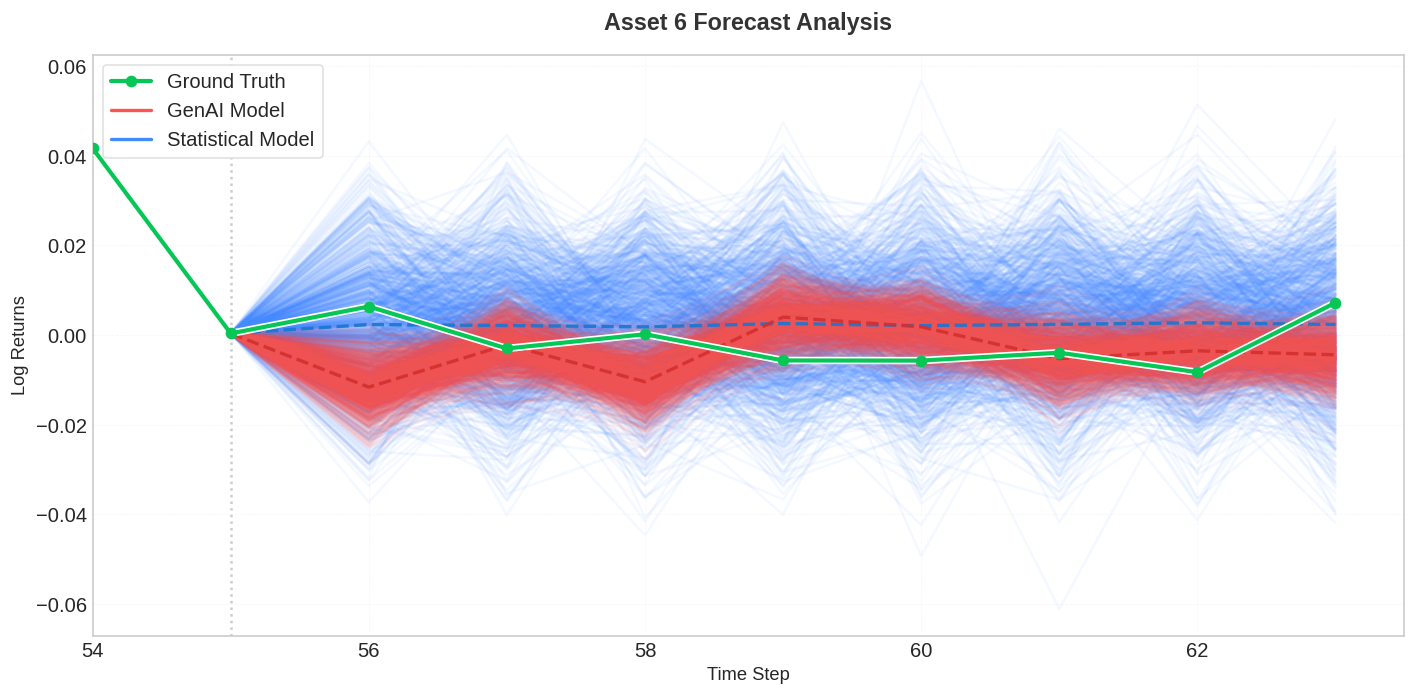

In [100]:
plot_final_revised(gt.cpu(), mc_sim_genai.cpu(), sim_stat.cpu(), asset_idx=6)

x_mc: torch.Size([1000, 9, 64, 14]) , cond_mc: torch.Size([1000, 2, 64, 14])


sim_only: torch.Size([1000, 9, 64, 14])
mc_sim_genai: torch.Size([1000, 8, 14])
steps_sim: 8
Close log returns: torch.Size([64, 14])
mc_sim_stat: torch.Size([1000, 8, 14])
gt: (8, 14)
dates: (8,)
torch.Size([8, 14]) torch.Size([8, 14])
Mu_genai: (14,), Sigma_genai: (14, 14)
Mu_stats: (14,), Sigma_stats: (14, 14)
weights_genai: (14,)
weights_stats: (14,)
Generating QuantStats Report...


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

Report saved to /home/narodom.y@FUSION.LAB/research/results/reports/quantstats/eval_best_tr100_d256_dff1024_l8_h2_t1000/bt0/sim0
torch.Size([8, 14]) torch.Size([8, 14])
Mu_genai: (14,), Sigma_genai: (14, 14)
Mu_stats: (14,), Sigma_stats: (14, 14)
weights_genai: (14,)
weights_stats: (14,)
Generating QuantStats Report...


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

...

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

Report saved to /home/narodom.y@FUSION.LAB/research/results/reports/quantstats/eval_best_tr100_d256_dff1024_l8_h2_t1000/bt0/sim168
torch.Size([8, 14]) torch.Size([8, 14])
Mu_genai: (14,), Sigma_genai: (14, 14)
Mu_stats: (14,), Sigma_stats: (14, 14)
weights_genai: (14,)
weights_stats: (14,)
Generating QuantStats Report...


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

Report saved to /home/narodom.y@FUSION.LAB/research/results/reports/quantstats/eval_best_tr100_d256_dff1024_l8_h2_t1000/bt0/sim169
torch.Size([8, 14]) torch.Size([8, 14])
Mu_genai: (14,), Sigma_genai: (14, 14)
Mu_stats: (14,), Sigma_stats: (14, 14)
weights_genai: (14,)
weights_stats: (14,)
Generating QuantStats Report...


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.

KeyboardInterrupt

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


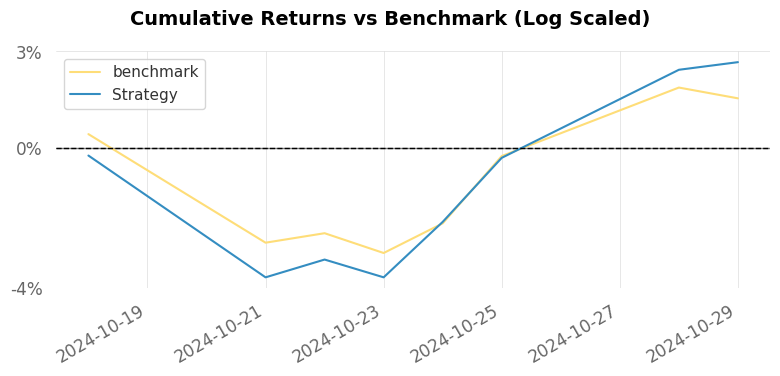

In [60]:
evaluation(test_loader, 1000)

In [ ]:
12

In [ ]:
def evaluation_oldversion(dataloader):
    count = 0
    
    eval_dir = os.path.join(REPORTS_QS_DIR, f"eval_{checkpoint_filename[:-3]}")
    os.makedirs(eval_dir, exist_ok=True)
    
    for batch in dataloader:
        dates = transform_dates(batch['date'])
        print(f"dates: {dates.shape}")
        # Monte Carlo
        # MC Genai
        x_mc, cond_mc = expand_mc_size(batch['x'], batch['cond'], n_samples)
        print(f"x_mc: {x_mc.shape} , cond_mc: {cond_mc.shape}")

        # simulate with inpaiting
        sim_full_scaled, sim_only_scaled =  engine.simulate(x_mc.to(device), cond_mc.to(device))
        
        sim_only = inverse_transform(sim_full_scaled.to(device), batch['x_mean'].to(device), batch['x_std'].to(device))
        print(f"sim_only: {sim_only.shape}")

        mc_sim_genai = sim_only[:, 1:, -1:, :].squeeze(2)
        print(f"mc_sim_genai: {mc_sim_genai.shape}")

        # MC Stats
        x_unscaled = inverse_transform(batch['x'], batch['x_mean'], batch['x_std'])
        close_log_returns = x_unscaled[0, 0, :, :]
        print(f"Close log returns: {close_log_returns.shape}")

        mc_sim_stat = monte_carlo_statistic(torch.as_tensor(close_log_returns), n_sims=n_samples, steps=sim_only.shape[1]) # [n_sims, steps, assets]
        print(f"mc_sim_stat: {mc_sim_stat.shape}")

        # Ground truth
        gt = x_unscaled
        gt = gt[0, 1:, -1:, :]
        gt = gt.squeeze(1)
        print(f"gt: {gt.shape}")
        

        # Portfolio management
        B_genai, F_genai, A_genai = mc_sim_genai.shape
        sim_genai_dist = mc_sim_genai.reshape(-1, A_genai) 
        
        B_stat, F_stat, A_stat = mc_sim_stat.shape
        sim_stat_dist = mc_sim_stat.reshape(-1, A_stat)

        risk_free_rate = 0.02/252
        weight_bounds = (0, 1)
        is_calc_distribution = True

        # New Dir per Batch contain sim
        # bt means batch test
        report_dir = os.path.join(eval_dir, f"bt{count}")
        os.makedirs(report_dir, exist_ok=True)
        
        for sim_idx in range(B_genai):
            sim_genai = mc_sim_genai[sim_idx, :, :]
            sim_stat  = mc_sim_stat[sim_idx, :, :]
            
            report_filename = f"sim{sim_idx}"
            portfolio = Portfolio(risk_free_rate, weight_bounds=weight_bounds, save_dir=report_dir)


            mu_genai, sigma_genai = portfolio.calc(sim_genai_dist)
            mu_stats, sigma_stats = portfolio.calc(sim_stat_dist)
            
       
        
        if is_calc_distribution:
            mu_genai, sigma_genai = portfolio.calc_distribution(sim_genai_dist.tolist())
            mu_stats, sigma_stats = portfolio.calc_distribution(sim_stat_dist.tolist())
        else:
            mu_genai, sigma_genai = portfolio.calc(sim_genai_dist)
            mu_stats, sigma_stats = portfolio.calc(sim_stat_dist)
        
        print(f"Mu_genai: {mu_genai.shape}, Sigma_genai: {sigma_genai.shape}")
        print(f"Mu_stats: {mu_stats.shape}, Sigma_stats: {sigma_stats.shape}")
        # logger.debug(f"Mu_genai: {mu_genai.shape}, Sigma_genai: {sigma_genai.shape}")
        # logger.debug(f"Mu_stats: {mu_stats.shape}, Sigma_stats: {sigma_stats.shape}")
        
        weights_genai = portfolio.optimize_weights(mu_genai, sigma_genai, risk_free_rate=risk_free_rate, scipy=True)
        weights_stats = portfolio.optimize_weights(mu_stats, sigma_stats, risk_free_rate=risk_free_rate, scipy=True)
        
        print(f"weights_genai: {weights_genai.shape}")
        print(f"weights_stats: {weights_stats.shape}")
        # logger.debug(f"weights_genai: {weights_genai.shape}")
        # logger.debug(f"weights_stats: {weights_stats.shape}")

        # rebalance_days = 1
        report = portfolio.back_test(weights=weights_genai, weights_benchmark=weights_stats, returns=gt, dates=dates[-8:], is_saved=True, filename=report_filename)
        count += 1

        break